# Projet Facebook100 - MELL Emma

## Configuration du notebook

Commencez par relancer le kernel en allant dans **Kernel -> Restart Kernel...**

### Style du notebook

In [1]:
# Style pour le Notebook
from IPython.core.display import HTML

def css_styling():
    styles = open("../styles/custom.css", "r").read()
    return HTML(styles)
css_styling()

### Vérification de la version de Python et de Networkx

In [2]:
import networkx as nx
from packaging import version
import sys
import matplotlib.pylab as plt

%matplotlib inline

print("Python version:", sys.version)
print("networkx version:", nx.__version__)

# assert networkx version is greater or equal to 2.6
assert version.parse(nx.__version__) >= version.parse("3.0")

# assert python version is greater that 3.7
assert sys.version_info[0] == 3
assert sys.version_info[1] >= 7 

# If working in colab mount the drive filesystem 
if 'google.colab' in str(get_ipython()):
    print('Working in colab')
    
    from google.colab import drive
    drive.mount('/content/drive')
else:
    print("working locally")

Python version: 3.12.3 (main, Mar 23 2026, 19:04:32) [GCC 13.3.0]
networkx version: 3.6.1
working locally


## Projet

### Question 2

#### a)

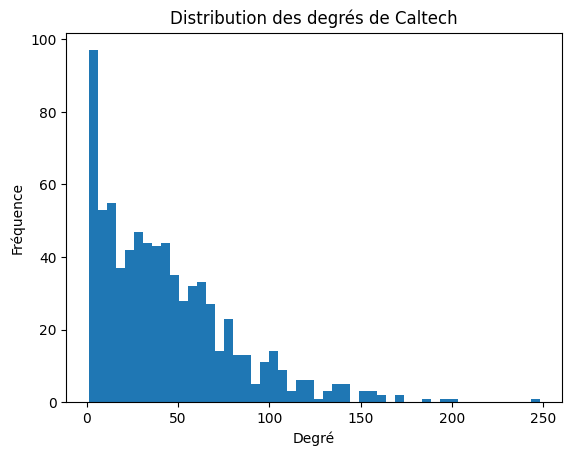

Métriques pour Caltech
Densité: 0.05742892519512591
Clustering global: 0.2912809635141533
Clustering moyen: 0.4091173048334612


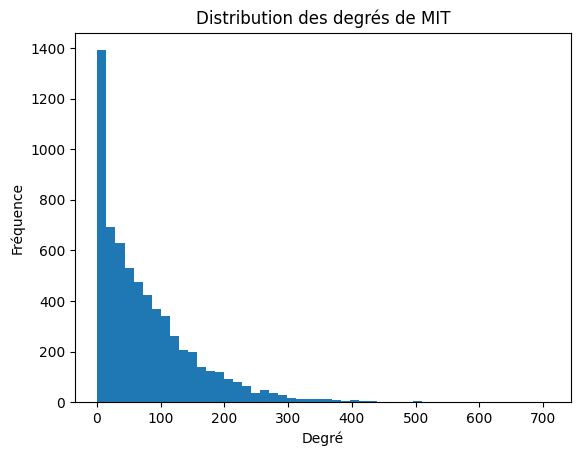

Métriques pour MIT
Densité: 0.012261341741110527
Clustering global: 0.1802884023054581
Clustering moyen: 0.27235999658838644


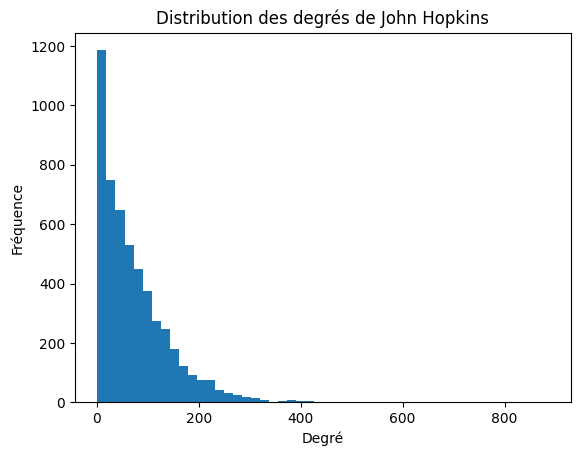

Métriques pour John Hopkins
Densité: 0.0140335136902954
Clustering global: 0.19316115952994883
Clustering moyen: 0.26900836180589566


In [3]:
import networkx as nx
import matplotlib.pylab as plt

# Charge le graphe et renvoie sa plus grande composante connexe
# Prend le chemin de la donnée en argument
def load_LCC(path):
    G = nx.read_gml(path)
    largest_cc = max(nx.connected_components(G), key=len)
    return G.subgraph(largest_cc).copy()

# Graphe des 3 réseaux
graphes = {"Caltech": load_LCC("../data/Caltech36.gml"),
           "MIT": load_LCC("../data/MIT8.gml"),
           "John Hopkins": load_LCC("../data/Johns Hopkins55.gml")}

for name, G in graphes.items():
    # Distribution des degrés
    degrees = [d for _, d in G.degree()]
    plt.hist(degrees, bins=50)
    plt.title(f"Distribution des degrés de {name}")
    plt.xlabel("Degré")
    plt.ylabel("Fréquence")
    plt.show()

    # Densité et clustering
    density = nx.density(G)
    global_clustering = nx.transitivity(G)
    local_clustering = nx.average_clustering(G)

    print(f"Métriques pour {name}")
    print(f"Densité: {density}")
    print(f"Clustering global: {global_clustering}")
    print(f"Clustering moyen: {local_clustering}")

#### b)

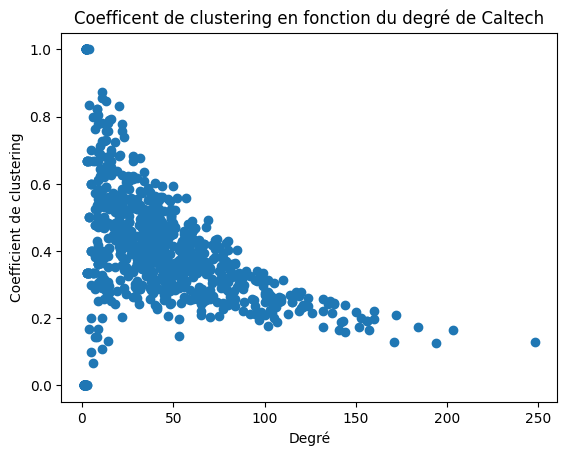

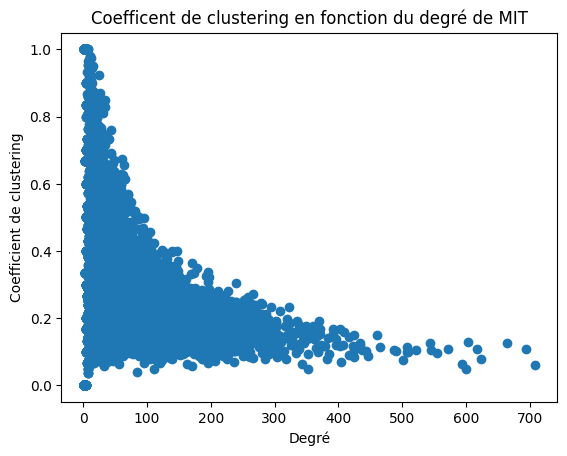

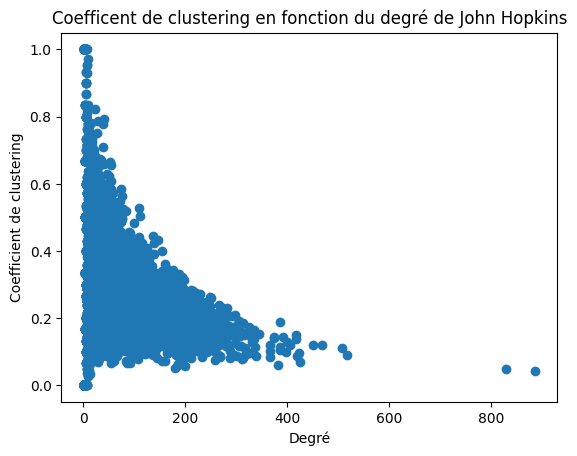

In [4]:
for name, G in graphes.items():
    degrees = dict(G.degree())
    clustering = nx.clustering(G)
    
    x = []
    y = []
    
    for node in G.nodes():
        x.append(degrees[node])
        y.append(clustering[node])

    plt.title(f"Coefficent de clustering en fonction du degré de {name}")
    plt.scatter(x, y)
    plt.xlabel("Degré")
    plt.ylabel("Coefficient de clustering")
    plt.show()

### Question 3

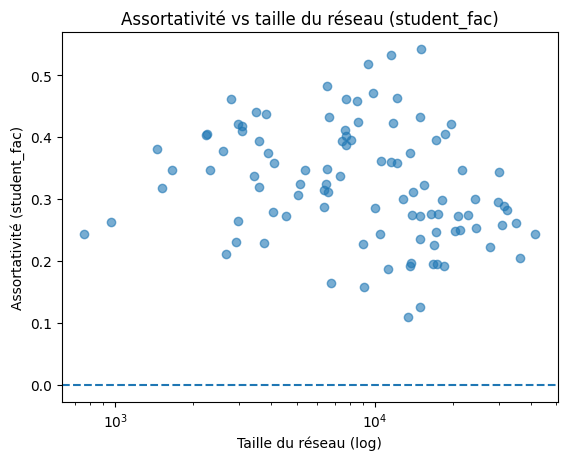

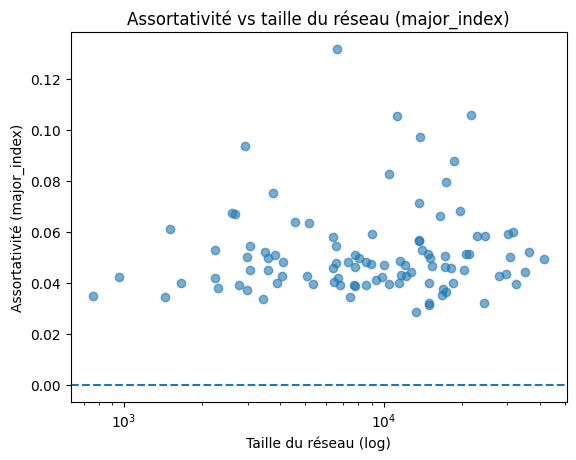

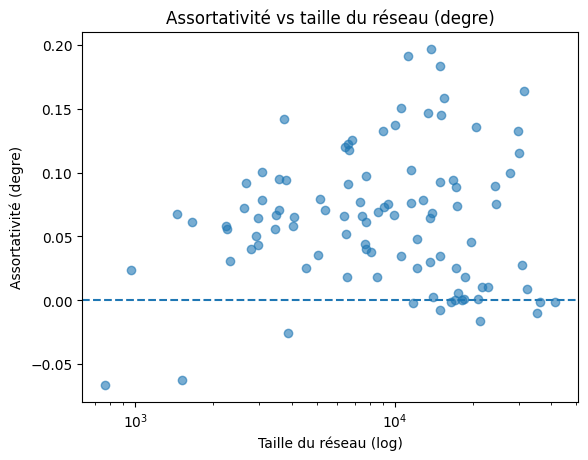

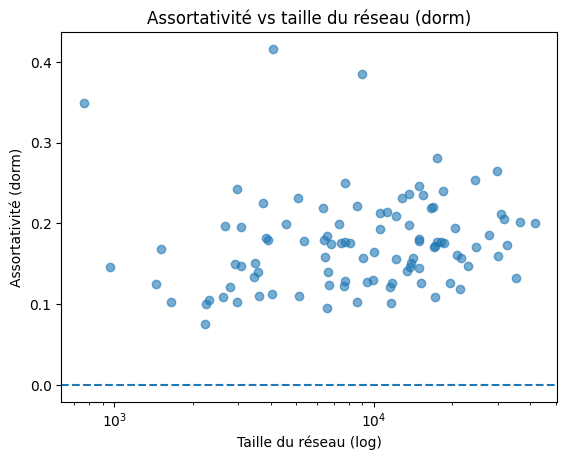

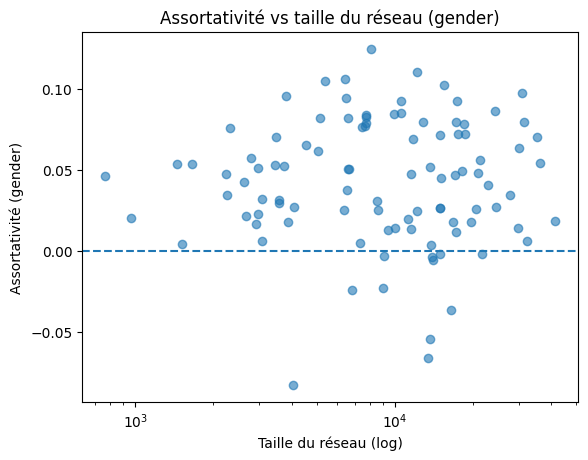

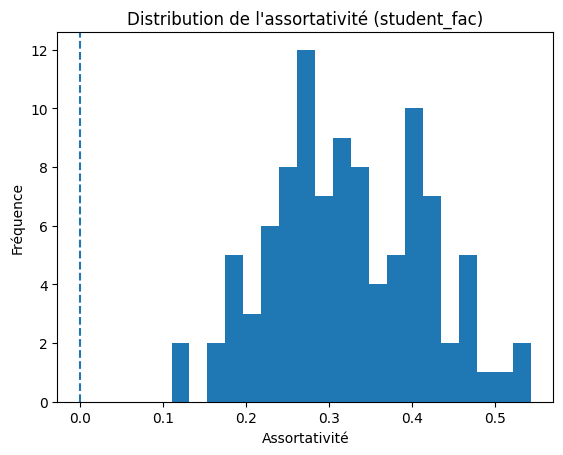

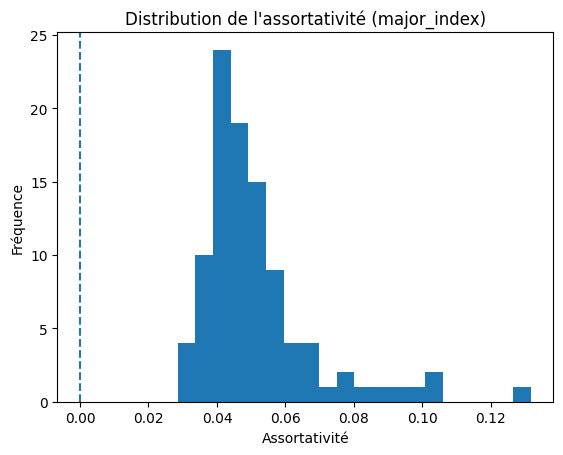

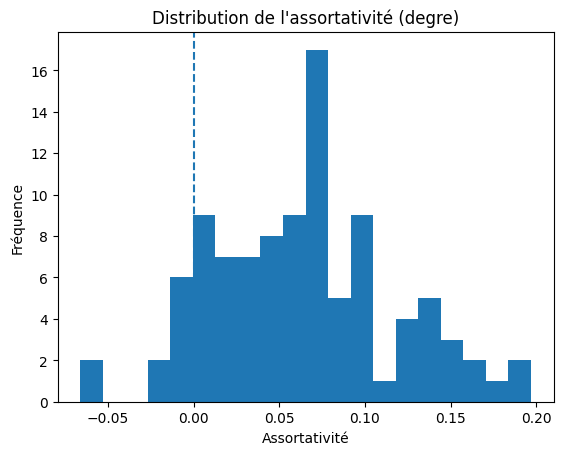

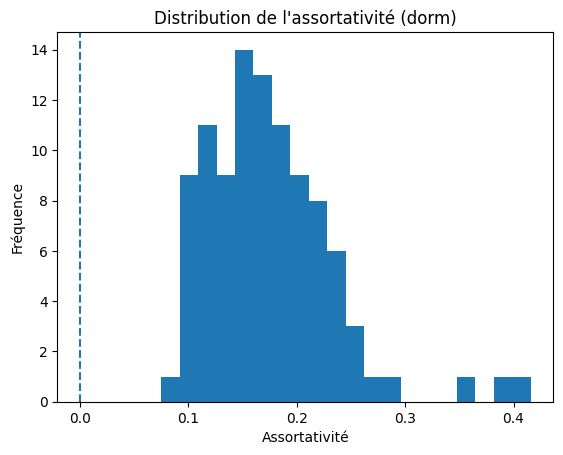

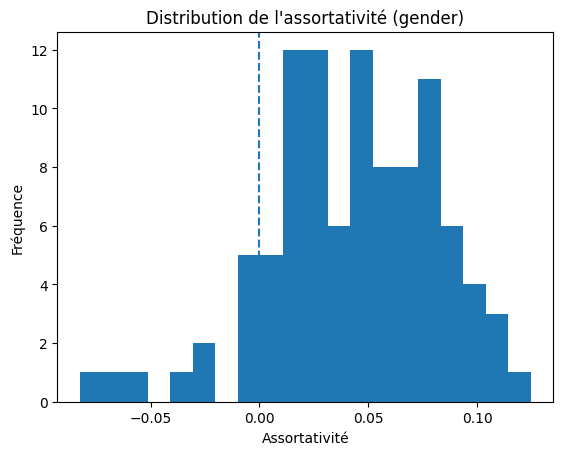

In [11]:
import networkx as nx
import matplotlib.pyplot as plt
import os
from tqdm import tqdm

# Attributs à analyser
# Il faut calculer le degré des noeuds car ce n'est pas un attribut direct des noeuds du graphe
attributes = ["student_fac", "major_index", "degre", "dorm", "gender"]

# Stockage des résultats
results = {}
for attr in attributes:
    results[attr] = []
sizes = []

# Chargement des graphes (n graphes)
# Charge tous les graphes du dataset si n > nombre de graphes du dataset ou n < 0
# On utilise n pour éviter de charger tous les graphes (car cela prend du temps)
n = -1
data_folder_path = "../data"

gml_files = [f for f in os.listdir(data_folder_path) if f.endswith(".gml")]
gml_files = gml_files[:n]
bar = tqdm(gml_files)
for file in bar:
    # Customisation de la barre de tqdm
    bar.set_description(f"Chargement de {file}")
    
    if file.endswith(".gml"):
        path = os.path.join(data_folder_path, file)

        try:
            # Chargement du graphe
            G = load_LCC(path)

            length = len(G)
            sizes.append(length)

            bar.set_description(f"{file} (n={length})")

            # Calcul de l'assortativité pour chaque attribut
            for attr in attributes:
                if attr != "degre":
                    r = nx.attribute_assortativity_coefficient(G, attr)
                else:
                    r = nx.degree_assortativity_coefficient(G)
                results[attr].append(r)
        except Exception as e:
            # Utilisé pour le debug
            print(f"Erreur avec {file} : {e}")

# Graphiques
for attr in attributes:
    plt.figure()
    plt.scatter(sizes, results[attr], alpha=0.6)
    plt.xscale("log")
    plt.axhline(0, linestyle='--')
    plt.xlabel("Taille du réseau (log)")
    plt.ylabel(f"Assortativité ({attr})")
    plt.title(f"Assortativité vs taille du réseau ({attr})")
    plt.show()

# Histogramme
for attr in attributes:
    plt.figure()
    plt.hist(results[attr], bins=20)
    plt.axvline(0, linestyle='--')
    plt.xlabel("Assortativité")
    plt.ylabel("Fréquence")
    plt.title(f"Distribution de l'assortativité ({attr})")
    plt.show()

### Question 4

#### b)

In [9]:
from abc import ABC, abstractmethod
import networkx as nx
import numpy as np
import progressbar

class LinkPrediction(ABC):
    def __init__(self, graph):
        """
        Constructor

        Parameters
        ----------
            graph: Networkx graph
        """
        self.graph = graph
        self.N = len(graph)

    def neighbors(self, v):
        """
        Return the neighbors list of a node

        Parameters
        ----------
            v: int
                node id

        Return
        ------
            neighbors_list: python list
        """
        neighbors_list = self.graph.neighbors(v)
        return list(neighbors_list)

    @abstractmethod
    def fit(self):
        raise NotImplementedError("Fit must be implemented")

In [10]:
class CommonNeighbors(LinkPrediction):
    def __init__(self, graph):
        super(CommonNeighbors, self).__init__(graph)

    def fit(self):
        scores = []
        nodes = list(self.graph.nodes())

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                u = nodes[i]
                v = nodes[j]

                # On fait de la prédiction de liens donc il ne faut pas que les 2 soient connectés
                if not self.graph.has_edge(u, v):
                    # On utilise des sets pour pouvoir calculer rapidement et facilement les intersection et union
                    # Voisins de u
                    nu = set(self.neighbors(u))
                    # Voisins de v
                    nv = set(self.neighbors(v))
                    # Intersection entre nu et nv
                    inter = nu & nv
                    score = len(inter)
                    scores.append((u, v, score))

        return scores

In [12]:
class Jaccard(LinkPrediction):
    def __init__(self, graph):
        super(Jaccard, self).__init__(graph)

    def fit(self):
        scores = []
        nodes = list(self.graph.nodes())

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                u = nodes[i]
                v = nodes[j]
                
                # On fait de la prédiction de liens donc il ne faut pas que les 2 soient connectés
                if not self.graph.has_edge(u, v):
                    # On utilise des sets pour pouvoir calculer rapidement et facilement les intersection et union
                    # Voisins de u
                    nu = set(self.neighbors(u))
                    # Voisins de v
                    nv = set(self.neighbors(v))
                    # Intersection entre nu et nv
                    inter = nu & nv
                    # Union entre nu et nv
                    union = nu | nv

                    if len(union) == 0:
                        score = 0
                    else:
                        score = len(inter)/len(union)

                    scores.append((u, v, score))

        return scores

In [13]:
from math import log

class AdamicAdar(LinkPrediction):
    def __init__(self, graph):
        super(AdamicAdar, self).__init__(graph)

    def fit(self):
        scores = []
        nodes = list(self.graph.nodes())

        for i in range(len(nodes)):
            for j in range(i+1, len(nodes)):
                u = nodes[i]
                v = nodes[j]
                
                # On fait de la prédiction de liens donc il ne faut pas que les 2 soient connectés
                if not self.graph.has_edge(u, v):
                    # On utilise des sets pour pouvoir calculer rapidement et facilement les intersection et union
                    # Voisins de u
                    nu = set(self.neighbors(u))
                    # Voisins de v
                    nv = set(self.neighbors(v))
                    # Intersection entre nu et nv
                    inter = nu & nv

                    score = 0
                    for z in inter:
                        deg = len(self.neighbors(z))
                        if deg > 1:
                            score += 1/log(deg)

                    scores.append((u, v, score))

        return scores

#### c)

In [23]:
import random
from tqdm import tqdm

def remove_edges(G_source, fraction):
    """Supprime une fraction des arêtes de manière random et renvoie ce nouveau graphe."""
    G = G_source.copy()
    edges = list(G.edges())

    # On calcule le nombre d'arête à supprimer
    nb_remove = int(len(edges) * fraction)
    e_removed = random.sample(edges, nb_remove)

    # On supprime les arêtes sélectionnées
    G.remove_edges_from(e_removed)

    return G, e_removed

def evaluate_model(scores, e_removed, k_list):
    results = {}
    
    # On tri les arêtes car le graphe est non orienté et si on ne le faisait pas on aurait des erreurs de calcul
    # Car on aurait (u, v) != (v, u)
    removed_set = set(tuple(sorted(e)) for e in e_removed)

    for k in k_list:
        top_k = scores[:k]

        # De même, on tri les arêtes
        predicted = set(tuple(sorted((u, v))) for u, v, _ in top_k)

        # Calcul des vrai positif
        tp = len(predicted & removed_set)

        # Precision : On n'a pas détecté des arêtes qui n'existe pas
        # |TP| + |FP| = k
        # Ce qui fait que top@k = precision@k
        if k > 0:
            precision = tp / k
        else:
            precision = 0

        # Recall : On n'a pas oublié de détecter des arêtes qui existe
        # |TP| + |FN| = len(removed_set)
        if len(removed_set) > 0:
            recall = tp / len(removed_set)
        else:
            recall = 0

        results[k] = (precision, recall)

    return results

def link_prediction(G_source, fractions):
    """Fait les étapes 2 à 5 de la 4c"""
    for fraction in fractions:
        print("---------------------------------------------")
        print(f"Fraction d'arêtes supprimées : {fraction}")
        # 2. Suppression d'une fraction des arêtes
        G_train, e_removed = remove_edges(G_source, fraction)
        
        # 3. Calcul de la prédiction de lien
        common_neighbors = CommonNeighbors(G_train)
        jaccard = Jaccard(G_train)
        adamic_adar = AdamicAdar(G_train)
        
        models = {
            "Common Neighbors": common_neighbors,
            "Jaccard": jaccard,
            "AdamicAdar": adamic_adar
        }
        
        for name, model in models.items():
            print(name)
            scores = model.fit()
    
            # 4. Tri des arêtes par score
            scores.sort(key=lambda x: x[2], reverse=True)
    
            # 5. Evaluation des modèles
            k_list = [50, 100, 200, 400]
            results = evaluate_model(scores, e_removed, k_list)
        
            for k, (precision, recall) in results.items():
                print(f"k={k} -> precision@k={precision:.4f}, recall@k={recall:.4f}")

# 1. Initialision du graphe
# (On n'utilise pas load_LCC car on veut travailler sur tout le graphe)
paths = ["../data/Caltech36.gml", "../data/Reed98.gml", "../data/Simmons81.gml"]
fractions = [0.05, 0.1, 0.15, 0.2]
bar = tqdm(paths)
for path in bar:
    bar.set_description(f"Chargement de {path}")
    G_source = nx.read_gml(path)
    link_prediction(G_source, fractions)

Chargement de ../data/Caltech36.gml:   0%|                | 0/3 [00:00<?, ?it/s]

---------------------------------------------
Fraction d'arêtes supprimées : 0.05
832
Common Neighbors
k=50 -> precision@k=0.6000, recall@k=0.0361
k=100 -> precision@k=0.4800, recall@k=0.0577
k=200 -> precision@k=0.3800, recall@k=0.0913
k=400 -> precision@k=0.2725, recall@k=0.1310
Jaccard
k=50 -> precision@k=0.3000, recall@k=0.0180
k=100 -> precision@k=0.2800, recall@k=0.0337
k=200 -> precision@k=0.2500, recall@k=0.0601
k=400 -> precision@k=0.2225, recall@k=0.1070
AdamicAdar
k=50 -> precision@k=0.5400, recall@k=0.0325
k=100 -> precision@k=0.4700, recall@k=0.0565
k=200 -> precision@k=0.3900, recall@k=0.0938
k=400 -> precision@k=0.2800, recall@k=0.1346
---------------------------------------------
Fraction d'arêtes supprimées : 0.1
1665
Common Neighbors
k=50 -> precision@k=0.6600, recall@k=0.0198
k=100 -> precision@k=0.6100, recall@k=0.0366
k=200 -> precision@k=0.5750, recall@k=0.0691
k=400 -> precision@k=0.4400, recall@k=0.1057
Jaccard
k=50 -> precision@k=0.4000, recall@k=0.0120
k=100 -

Chargement de ../data/Reed98.gml:  33%|███▋       | 1/3 [00:27<00:54, 27.03s/it]

k=50 -> precision@k=0.8200, recall@k=0.0123
k=100 -> precision@k=0.7800, recall@k=0.0234
k=200 -> precision@k=0.7250, recall@k=0.0435
k=400 -> precision@k=0.6500, recall@k=0.0781
---------------------------------------------
Fraction d'arêtes supprimées : 0.05
940
Common Neighbors
k=50 -> precision@k=0.2200, recall@k=0.0117
k=100 -> precision@k=0.2100, recall@k=0.0223
k=200 -> precision@k=0.1750, recall@k=0.0372
k=400 -> precision@k=0.1325, recall@k=0.0564
Jaccard
k=50 -> precision@k=0.1800, recall@k=0.0096
k=100 -> precision@k=0.1900, recall@k=0.0202
k=200 -> precision@k=0.1850, recall@k=0.0394
k=400 -> precision@k=0.1950, recall@k=0.0830
AdamicAdar
k=50 -> precision@k=0.2000, recall@k=0.0106
k=100 -> precision@k=0.2100, recall@k=0.0223
k=200 -> precision@k=0.1750, recall@k=0.0372
k=400 -> precision@k=0.1300, recall@k=0.0553
---------------------------------------------
Fraction d'arêtes supprimées : 0.1
1881
Common Neighbors
k=50 -> precision@k=0.4200, recall@k=0.0112
k=100 -> precis

Chargement de ../data/Simmons81.gml:  67%|█████▎  | 2/3 [01:06<00:34, 34.07s/it]

k=50 -> precision@k=0.6200, recall@k=0.0082
k=100 -> precision@k=0.5900, recall@k=0.0157
k=200 -> precision@k=0.5100, recall@k=0.0271
k=400 -> precision@k=0.4750, recall@k=0.0505
---------------------------------------------
Fraction d'arêtes supprimées : 0.05
1649
Common Neighbors
k=50 -> precision@k=0.5000, recall@k=0.0152
k=100 -> precision@k=0.4300, recall@k=0.0261
k=200 -> precision@k=0.3050, recall@k=0.0370
k=400 -> precision@k=0.2425, recall@k=0.0588
Jaccard
k=50 -> precision@k=0.1400, recall@k=0.0042
k=100 -> precision@k=0.1600, recall@k=0.0097
k=200 -> precision@k=0.1300, recall@k=0.0158
k=400 -> precision@k=0.1300, recall@k=0.0315
AdamicAdar
k=50 -> precision@k=0.5200, recall@k=0.0158
k=100 -> precision@k=0.4100, recall@k=0.0249
k=200 -> precision@k=0.3100, recall@k=0.0376
k=400 -> precision@k=0.2625, recall@k=0.0637
---------------------------------------------
Fraction d'arêtes supprimées : 0.1
3298
Common Neighbors
k=50 -> precision@k=0.8400, recall@k=0.0127
k=100 -> preci

Chargement de ../data/Simmons81.gml:  67%|█████▎  | 2/3 [01:59<00:59, 59.55s/it]


KeyboardInterrupt: 